In [5]:
import rasterio

dem = rasterio.open("../data/raw/output_SRTMGL1_v2.tif")   

print(dem.crs)
print(dem.bounds)
print(dem.shape)
print(dem.res)

EPSG:4326
BoundingBox(left=73.4998611111447, bottom=18.38013888888338, right=74.01986111114476, top=18.62013888888341)
(864, 1872)
(0.0002777777777778146, 0.0002777777777778146)


In [6]:
band1 = dem.read(1)
print(band1.min(), band1.max(), band1.mean())

516 1199 668.706547142094


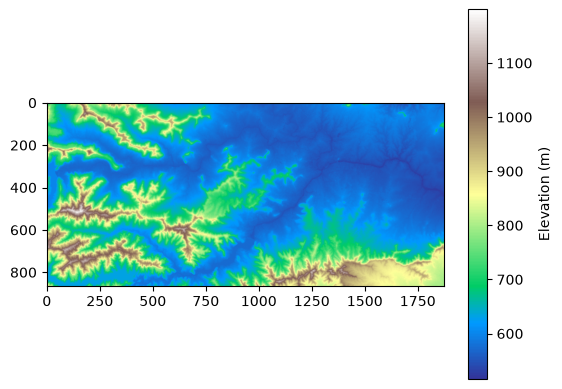

In [7]:
import matplotlib.pyplot as plt

plt.imshow(band1, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.show()

In [8]:
print(dem.nodata)

-32768.0


In [9]:
pip install rasterstats


   ---------------------------------------- 0/3 [simplejson]
   ---------------------------------------- 0/3 [simplejson]
   ---------------------------------------- 0/3 [simplejson]
   -------------------------- ------------- 2/3 [rasterstats]
   ---------------------------------------- 3/3 [rasterstats]

Note: you may need to restart the kernel to use updated packages.


In [11]:
import geopandas as gpd

wards = gpd.read_file("../data/raw/pune_wards.geojson")

In [12]:
from rasterstats import zonal_stats

stats = zonal_stats(wards, "../data/raw/output_SRTMGL1_v2.tif", stats=["mean", "min", "max"])

In [13]:
wards["elevation_mean"] = [s["mean"] for s in stats]
print(wards[["Name2", "elevation_mean"]].sort_values("elevation_mean"))

                                               Name2  elevation_mean
20                           Koregaon park - Mundhwa      553.452360
21                          Manjari Bk. - Shewalwadi      553.549882
9                  Shivajinagar Gaothan - Sangamwadi      555.418149
7                                 Kalas - Phulenagar      555.937207
6                        Kalyaninagar - Nagpur Chawl      556.344918
19      Pune Station -Matoshri Ramabai Ambedkar Road      556.414560
8                                            Yerwada      556.833203
18  Chhatrapati Shivaji Maharaj Stadium - Rasta peth      556.865385
5                            Vadgaon Sheri - Ramwadi      557.267776
17                         Shaniwarwada - Kasba Peth      557.337143
4                       West Kharadi - Vadgaon Sheri      557.535746
16                         Shaniwar peth - Navi Peth      560.538278
22                       Sadesataranali - Aakashwani      561.668637
23                    Magarpatta -

In [14]:
from shapely.geometry import Point

candidates = {
    "Ekta Nagar": Point(73.82440214806881, 18.479610594634398),
    "Bhimnagar": Point(73.77072544898591, 18.458227224690205),
}

for name, point in candidates.items():
    match = wards[wards.contains(point)]
    print(f"--- {name} ---")
    print(match[["wardnum", "Name2"]])
    print()

--- Ekta Nagar ---
    wardnum                   Name2
50       52  Nanded City - Sun City

--- Bhimnagar ---
    wardnum                    Name2
32       34  Warje - Kondhave Dhavde



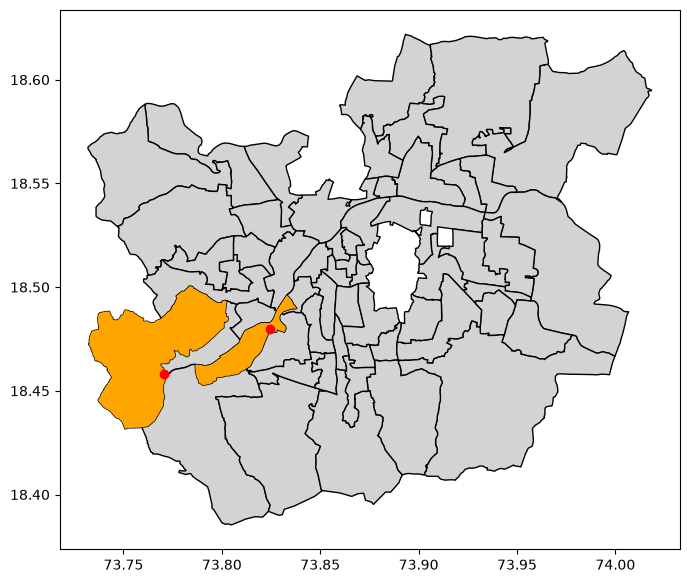

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
wards.plot(ax=ax, color="lightgrey", edgecolor="black")
wards[wards["wardnum"].isin([34, 52])].plot(ax=ax, color="orange")

ekta_point = Point(73.82440214806881, 18.479610594634398)
bhim_point = Point(73.77072544898591, 18.458227224690205)
ax.scatter([ekta_point.x, bhim_point.x], [ekta_point.y, bhim_point.y], color="red", zorder=5)

plt.show()

In [16]:
candidates2 = {
    "Shivne": Point(73.78274612064936, 18.466266736881444),
    "Kondhwe Dhawade": Point(73.77125249465733, 18.4587283574513),
}

for name, point in candidates2.items():
    match = wards[wards.contains(point)]
    print(f"--- {name} ---")
    print(match[["wardnum", "Name2"]])
    print()

--- Shivne ---
    wardnum                          Name2
33       35  Ramnagar - Uttamnagar Shivane

--- Kondhwe Dhawade ---
    wardnum                    Name2
32       34  Warje - Kondhave Dhavde



In [18]:
locality_to_ward = {
    "Ekta Nagar": "Nanded City - Sun City",           # ward 52
    "Bhimnagar": "Warje - Kondhave Dhavde",            # ward 34
    "Shivne": "Ramnagar - Uttamnagar Shivane",         # ward 35
    "Kondhwe Dhawade": "Warje - Kondhave Dhavde",      # ward 34
}

wards["incident_count"] = wards["Name2"].map(
    lambda name: sum(1 for w in locality_to_ward.values() if w == name)
)
print(wards[wards["incident_count"] > 0][["Name2", "incident_count"]])

                            Name2  incident_count
32        Warje - Kondhave Dhavde               2
33  Ramnagar - Uttamnagar Shivane               1
50         Nanded City - Sun City               1


In [32]:
wards = wards.rename(columns={"incident_count": "dam_discharge_incident_count"})
features = wards[["wardnum", "Name2", "elevation_mean", "dam_discharge_incident_count"]].copy()

In [33]:
print(features.columns)

Index(['wardnum', 'Name2', 'elevation_mean', 'dam_discharge_incident_count'], dtype='str')


In [27]:
import pandas as pd
df_rain = pd.read_csv("../data/processed/shivajinagar_daily_2014_2026.csv")

total_days = len(df_rain)
heavy_rain_days = (df_rain["rainfall"] > 64.5).sum()   # IMD's "heavy rainfall" threshold 
max_daily_rainfall = df_rain["rainfall"].max()
mean_daily_rainfall = df_rain["rainfall"].mean()

features["mean_daily_rainfall"] = mean_daily_rainfall
features["max_daily_rainfall"] = max_daily_rainfall
features["heavy_rain_day_pct"] = heavy_rain_days / total_days

In [34]:
wards["mean_daily_rainfall"] = mean_daily_rainfall
wards["max_daily_rainfall"] = max_daily_rainfall
wards["heavy_rain_day_pct"] = heavy_rain_days / total_days

features = wards[["wardnum", "Name2", "elevation_mean", "dam_discharge_incident_count",
                   "mean_daily_rainfall", "max_daily_rainfall", "heavy_rain_day_pct"]].copy()

print(features.columns)
print(features.head())

Index(['wardnum', 'Name2', 'elevation_mean', 'dam_discharge_incident_count',
       'mean_daily_rainfall', 'max_daily_rainfall', 'heavy_rain_day_pct'],
      dtype='str')
   wardnum                         Name2  elevation_mean  \
0        1        Dhanori - Vishrantwadi      582.621172   
1        2     Tingrenagar - Sanjay Park      571.087999   
2        3         Lohegaon - Vimannagar      589.849467   
3        4        East Kharadi - Wagholi      576.923163   
4        5  West Kharadi - Vadgaon Sheri      557.535746   

   dam_discharge_incident_count  mean_daily_rainfall  max_daily_rainfall  \
0                             0             4.853584               133.0   
1                             0             4.853584               133.0   
2                             0             4.853584               133.0   
3                             0             4.853584               133.0   
4                             0             4.853584               133.0   

   heavy_ra

In [35]:
wards.to_csv("../data/processed/ward_features_v1.csv", index=False)

In [36]:
wards.head()

,tessellate,extrude,visibility,wardnum,origin,Name1,Name2,geometry,elevation_mean,dam_discharge_incident_count,mean_daily_rainfall,max_daily_rainfall,heavy_rain_day_pct
0,-1,0,-1,1,http://www.pmc.gov.in/sites/default/files/fina...,01 Dhanori - Vishrantwadi,Dhanori - Vishrantwadi,"POLYGON ((73.90771 18.60121, 73.9078 18.6015, ...",582.621172,0,4.853584,133.0,0.009442
1,-1,0,-1,2,http://www.pmc.gov.in/sites/default/files/fina...,02 Tingrenagar - Sanjay Park,Tingrenagar - Sanjay Park,"POLYGON ((73.91178 18.59201, 73.91113 18.592, ...",571.087999,0,4.853584,133.0,0.009442
2,-1,0,-1,3,http://www.pmc.gov.in/sites/default/files/fina...,03 Lohegaon - Vimannagar,Lohegaon - Vimannagar,"POLYGON ((73.93051 18.62044, 73.9292 18.62066,...",589.849467,0,4.853584,133.0,0.009442
3,-1,0,-1,4,http://www.pmc.gov.in/sites/default/files/fina...,04 East Kharadi - Wagholi,East Kharadi - Wagholi,"POLYGON ((74.01045 18.60401, 74.01013 18.60453...",576.923163,0,4.853584,133.0,0.009442
4,-1,0,-1,5,http://www.pmc.gov.in/sites/default/files/fina...,05 West Kharadi - Vadgaon Sheri,West Kharadi - Vadgaon Sheri,"POLYGON ((73.93445 18.5636, 73.93381 18.56359,...",557.535746,0,4.853584,133.0,0.009442
